<a href="https://colab.research.google.com/github/shamsi123/X-LXMERT-anime-implementation/blob/main/xlxmert_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-LXMERT Implementation: Vision-Language Model for Caption, QA & Story Generation

This notebook implements the X-LXMERT architecture (Cho et al., 2020) that combines a **Base Language Model** with a **Vision Transformer (ViT)** to generate textual clues (captions, QA, stories) for images with new viewpoints, plus a **SPADE-based image generator**.

## Architecture overview
1. **Visual stream** &mdash; ROI features + quantization + uniform mask + position features  
2. **Language stream** &mdash; tokenized text with `[CLS]`, `[MASK]`, `[EOS]`  
3. **Object-Relationship Encoder** &mdash; self-attention over visual features  
4. **Language Encoder** &mdash; self-attention over text features  
5. **Cross-Modality Encoder** &mdash; bidirectional cross-attention between the two streams  
6. **Heads** &mdash; Cluster-Centroid Classification, Cross-Modality Matching & QA, Masked Cross-Modality LM  
7. **Generator** &mdash; SPADE ResBlocks producing an image; **Discriminator** with feature-matching, adversarial, AC-GAN and perceptual losses  
8. **Evaluation** &mdash; Inception Score (IS) and Fr&eacute;chet Inception Distance (FID)

## 1. Setup &mdash; install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATA_DIR = '/content/drive/MyDrive/LJMUThsis/anime_xformer/data'

In [3]:
!pip install colab_ssh --quiet
from colab_ssh import launch_ssh_cloudflared
launch_ssh_cloudflared(password="mypass123")

In [4]:
# Run once. Comment out if already installed.
!pip install -q torch torchvision transformers scipy numpy matplotlib pillow

In [6]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Visual stream &mdash; ViT-based ROI feature extractor

Extracts patch-level features and applies a `Quantize -> UniformMask -> +PosEmbed` pipeline,
matching the visual front-end shown in the X-LXMERT figure.

In [7]:
class PatchEmbed(nn.Module):
    """Split image into patches and project to embedding dimension (ViT-style)."""
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)               # B, E, H/P, W/P
        x = x.flatten(2).transpose(1, 2)  # B, N, E
        return x


class VisualQuantizer(nn.Module):
    """Codebook-based quantizer used by X-LXMERT to discretize ROI features into cluster centroids."""
    def __init__(self, num_codes=1024, embed_dim=768):
        super().__init__()
        self.codebook = nn.Embedding(num_codes, embed_dim)
        nn.init.uniform_(self.codebook.weight, -1.0 / num_codes, 1.0 / num_codes)

    def forward(self, x):
        # x: B, N, E  -> nearest codebook entry
        flat = x.reshape(-1, x.size(-1))
        dist = (flat.pow(2).sum(1, keepdim=True)
                - 2 * flat @ self.codebook.weight.t()
                + self.codebook.weight.pow(2).sum(1))
        idx = dist.argmin(dim=1)
        quantized = self.codebook(idx).view_as(x)
        # straight-through estimator so gradients flow back to the encoder
        quantized_st = x + (quantized - x).detach()
        return quantized_st, idx.view(x.shape[:-1])


class VisualFrontEnd(nn.Module):
    """ROI feature extractor: PatchEmbed -> Quantize -> UniformMask -> +PosEmbed."""
    def __init__(self, img_size=224, patch_size=16, embed_dim=768, num_codes=1024, mask_prob=0.15):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        self.quantizer = VisualQuantizer(num_codes, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches, embed_dim))
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mask_prob = mask_prob
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, images, apply_mask=True):
        feats = self.patch_embed(images)          # B, N, E
        feats, code_ids = self.quantizer(feats)   # B, N, E
        if apply_mask and self.training:
            B, N, _ = feats.shape
            mask = (torch.rand(B, N, device=feats.device) < self.mask_prob).unsqueeze(-1)
            feats = torch.where(mask, self.mask_token.expand_as(feats), feats)
        feats = feats + self.pos_embed
        return feats, code_ids

## 3. Language stream &mdash; token + position embedding

In [8]:
class TextEmbedding(nn.Module):
    def __init__(self, vocab_size=30522, max_len=64, embed_dim=768, pad_id=0):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos = nn.Embedding(max_len, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, ids):
        pos = torch.arange(ids.size(1), device=ids.device).unsqueeze(0).expand_as(ids)
        return self.norm(self.tok(ids) + self.pos(pos))

## 4. Encoder building blocks &mdash; self-attention and cross-attention

In [9]:
class SelfAttnBlock(nn.Module):
    def __init__(self, dim=768, heads=12, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x, key_padding_mask=None):
        h = self.norm1(x)
        a, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x


class CrossAttnBlock(nn.Module):
    """One direction of cross-modality attention (query <- key/value from the other modality)."""
    def __init__(self, dim=768, heads=12, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm_mlp = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, q, kv, kv_padding_mask=None):
        a, _ = self.attn(self.norm_q(q), self.norm_kv(kv), self.norm_kv(kv),
                         key_padding_mask=kv_padding_mask, need_weights=False)
        q = q + a
        q = q + self.mlp(self.norm_mlp(q))
        return q

## 5. X-LXMERT encoder &mdash; ObjectRel + Language + Cross-Modality

In [15]:
class XLXMERT(nn.Module):
    def __init__(self,
                 vocab_size=30522,
                 max_text_len=64,
                 dim=768,
                 n_obj_layers=5,
                 n_lang_layers=9,
                 n_cross_layers=5,
                 num_codes=1024,
                 num_qa_answers=3129,
                 heads=12):
        super().__init__()
        assert dim % heads == 0, f'dim ({dim}) must be divisible by heads ({heads})'
        self.visual = VisualFrontEnd(embed_dim=dim, num_codes=num_codes)
        self.text   = TextEmbedding(vocab_size, max_text_len, dim)

        self.obj_encoder  = nn.ModuleList([SelfAttnBlock(dim, heads=heads) for _ in range(n_obj_layers)])
        self.lang_encoder = nn.ModuleList([SelfAttnBlock(dim, heads=heads) for _ in range(n_lang_layers)])

        self.cross_v2l = nn.ModuleList([CrossAttnBlock(dim, heads=heads) for _ in range(n_cross_layers)])
        self.cross_l2v = nn.ModuleList([CrossAttnBlock(dim, heads=heads) for _ in range(n_cross_layers)])

        # heads
        self.cluster_head = nn.Linear(dim, num_codes)          # Cluster-Centroid Classification
        self.match_head   = nn.Linear(dim, 2)                  # Cross-Modality Matching
        self.qa_head      = nn.Linear(dim, num_qa_answers)     # QA
        self.mlm_head     = nn.Linear(dim, vocab_size)         # Masked Cross-Modality LM

    def forward(self, images, text_ids, text_pad_mask=None):
        v, code_ids = self.visual(images)
        t = self.text(text_ids)

        for blk in self.obj_encoder:
            v = blk(v)
        for blk in self.lang_encoder:
            t = blk(t, key_padding_mask=text_pad_mask)

        for blk_v, blk_l in zip(self.cross_v2l, self.cross_l2v):
            v_new = blk_v(v, t, kv_padding_mask=text_pad_mask)
            t_new = blk_l(t, v)
            v, t  = v_new, t_new

        cls = t[:, 0]  # [CLS] pooled representation
        return {
            'visual_seq': v,
            'text_seq': t,
            'pooled': cls,
            'cluster_logits': self.cluster_head(v),
            'match_logits':   self.match_head(cls),
            'qa_logits':      self.qa_head(cls),
            'mlm_logits':     self.mlm_head(t),
            'visual_code_targets': code_ids,
        }

## 6. SPADE-style image generator and discriminator

The bottom row of the architecture figure shows quantized ROI features being upsampled through SPADE ResBlks (`3x3 Conv` interleaved with `SPADE ResBlk`s) to produce an image, with a discriminator providing **feature-matching, adversarial, AC-GAN and perceptual** losses.

In [16]:
class SPADE(nn.Module):
    """Spatially-adaptive normalization conditioned on a feature map (the segmentation/ROI map)."""
    def __init__(self, norm_nc, label_nc, hidden=128):
        super().__init__()
        self.bn = nn.BatchNorm2d(norm_nc, affine=False)
        self.shared = nn.Sequential(nn.Conv2d(label_nc, hidden, 3, padding=1), nn.ReLU(True))
        self.gamma = nn.Conv2d(hidden, norm_nc, 3, padding=1)
        self.beta = nn.Conv2d(hidden, norm_nc, 3, padding=1)

    def forward(self, x, segmap):
        norm = self.bn(x)
        segmap = F.interpolate(segmap, size=x.shape[-2:], mode='nearest')
        h = self.shared(segmap)
        return norm * (1 + self.gamma(h)) + self.beta(h)


class SPADEResBlk(nn.Module):
    def __init__(self, in_c, out_c, label_nc):
        super().__init__()
        mid = min(in_c, out_c)
        self.spade1 = SPADE(in_c, label_nc)
        self.conv1 = nn.Conv2d(in_c, mid, 3, padding=1)
        self.spade2 = SPADE(mid, label_nc)
        self.conv2 = nn.Conv2d(mid, out_c, 3, padding=1)
        self.skip = nn.Conv2d(in_c, out_c, 1, bias=False) if in_c != out_c else nn.Identity()

    def forward(self, x, seg):
        h = self.conv1(F.leaky_relu(self.spade1(x, seg), 0.2))
        h = self.conv2(F.leaky_relu(self.spade2(h, seg), 0.2))
        return h + self.skip(x)


class Generator(nn.Module):
    """Generates a 128x128 image from quantized ROI features (the 2048 x 8 x 8 grid in the figure)."""
    def __init__(self, in_dim=768, label_nc=768):
        super().__init__()
        self.fc = nn.Conv2d(in_dim, 1024, 1)
        self.b1 = SPADEResBlk(1024, 512, label_nc)   # 8x8
        self.b2 = SPADEResBlk(512, 256, label_nc)    # 16x16
        self.b3 = SPADEResBlk(256, 128, label_nc)    # 32x32
        self.b4 = SPADEResBlk(128, 64, label_nc)     # 64x64
        self.to_rgb = nn.Conv2d(64, 3, 3, padding=1)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, roi_feats):
        # roi_feats: B, N=64, E -> B, E, 8, 8
        B, N, E = roi_feats.shape
        side = int(math.sqrt(N))
        seg = roi_feats.transpose(1, 2).reshape(B, E, side, side)
        x = self.fc(seg)
        x = self.b1(x, seg)
        x = self.b2(self.up(x), seg)
        x = self.b3(self.up(x), seg)
        x = self.b4(self.up(x), seg)
        return torch.tanh(self.to_rgb(x))


class Discriminator(nn.Module):
    """PatchGAN-style discriminator that also returns intermediate features (for feature-matching loss)
    and an auxiliary class prediction (for AC-GAN loss)."""
    def __init__(self, num_classes=1000):
        super().__init__()
        def block(i, o, s=2):
            return nn.Sequential(nn.Conv2d(i, o, 4, s, 1), nn.LeakyReLU(0.2, True))
        self.b1 = block(3, 64)
        self.b2 = block(64, 128)
        self.b3 = block(128, 256)
        self.b4 = block(256, 512, s=1)
        self.real_head = nn.Conv2d(512, 1, 4, 1, 1)
        self.cls_head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(512, num_classes))

    def forward(self, x):
        f1 = self.b1(x); f2 = self.b2(f1); f3 = self.b3(f2); f4 = self.b4(f3)
        return self.real_head(f4), self.cls_head(f4), [f1, f2, f3, f4]

## 7. Loss functions

**Encoder pre-training losses** (top half of the figure):
- Cluster-Centroid Classification: cross-entropy over masked visual tokens vs. codebook ids  
- Cross-Modality Matching: binary `Yes/No` matching of (image, text) pairs  
- QA: cross-entropy over the answer vocabulary  
- Masked Cross-Modality LM: cross-entropy over masked text tokens  

**Generator losses** (bottom half):
- Feature-matching loss across discriminator layers  
- Adversarial (hinge) loss  
- AC-GAN classification loss  
- Perceptual (VGG) loss

In [17]:
def encoder_pretrain_loss(out, mlm_targets, qa_target, match_target, mask_indices, weights=None):
    w = weights or {'cluster': 1.0, 'match': 1.0, 'qa': 1.0, 'mlm': 1.0}
    B, N, K = out['cluster_logits'].shape
    # Cluster-Centroid Classification (only on masked visual positions)
    cluster_loss = F.cross_entropy(
        out['cluster_logits'][mask_indices],
        out['visual_code_targets'][mask_indices],
    )
    match_loss = F.cross_entropy(out['match_logits'], match_target)
    qa_loss = F.cross_entropy(out['qa_logits'], qa_target)
    mlm_loss = F.cross_entropy(out['mlm_logits'].reshape(-1, out['mlm_logits'].size(-1)),
                               mlm_targets.reshape(-1), ignore_index=-100)
    return (w['cluster'] * cluster_loss + w['match'] * match_loss
            + w['qa'] * qa_loss + w['mlm'] * mlm_loss)


def hinge_d_loss(real_logits, fake_logits):
    return F.relu(1.0 - real_logits).mean() + F.relu(1.0 + fake_logits).mean()

def hinge_g_loss(fake_logits):
    return -fake_logits.mean()

def feature_matching_loss(real_feats, fake_feats):
    return sum(F.l1_loss(f, r.detach()) for r, f in zip(real_feats, fake_feats)) / len(real_feats)


class VGGPerceptual(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=None).features
        self.slices = nn.ModuleList([vgg[:4], vgg[4:9], vgg[9:16], vgg[16:23]]).eval()
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x, y):
        loss = 0.0
        for s in self.slices:
            x, y = s(x), s(y)
            loss = loss + F.l1_loss(x, y)
        return loss

In [14]:
import inspect
print(inspect.signature(XLXMERT.__init__))

(self, vocab_size=30522, max_text_len=64, dim=768, n_obj_layers=5, n_lang_layers=9, n_cross_layers=5, num_codes=1024, num_qa_answers=3129)


## 8. Sanity check &mdash; forward pass on a synthetic batch

In [19]:
# Use a smaller config so this runs on CPU.
#model = XLXMERT(vocab_size=5000, max_text_len=32, dim=256,
                #n_obj_layers=2, n_lang_layers=2, n_cross_layers=2,
                #num_codes=512, num_qa_answers=100).to(device)

                # Use a smaller config so this runs on CPU.
model = XLXMERT(vocab_size=5000, max_text_len=32, dim=256,
                n_obj_layers=2, n_lang_layers=2, n_cross_layers=2,
                num_codes=512, num_qa_answers=100,
                heads=8).to(device)

B = 2
img = torch.randn(B, 3, 224, 224, device=device)
txt = torch.randint(1, 5000, (B, 32), device=device)
txt[:, 0] = 101  # fake [CLS]

model.train()
out = model(img, txt)
for k, v in out.items():
    if torch.is_tensor(v):
        print(f'{k:22s} {tuple(v.shape)}')

# fake targets
mlm_targets = torch.full_like(txt, -100)
mlm_targets[:, 5] = txt[:, 5]  # one masked position per row
qa_target = torch.randint(0, 100, (B,), device=device)
match_target = torch.randint(0, 2, (B,), device=device)
mask_indices = torch.zeros_like(out['visual_code_targets'], dtype=torch.bool)
mask_indices[:, :3] = True
loss = encoder_pretrain_loss(out, mlm_targets, qa_target, match_target, mask_indices)
print(f'\nencoder pre-training loss = {loss.item():.4f}')

visual_seq             (2, 196, 256)
text_seq               (2, 32, 256)
pooled                 (2, 256)
cluster_logits         (2, 196, 512)
match_logits           (2, 2)
qa_logits              (2, 100)
mlm_logits             (2, 32, 5000)
visual_code_targets    (2, 196)

encoder pre-training loss = 20.3408


## 9. Generator sanity check

In [20]:
G = Generator(in_dim=256, label_nc=256).to(device)
D = Discriminator(num_classes=100).to(device)

# Use only 64 visual tokens (8x8 grid) for the generator path
roi = out['visual_seq'][:, :64]
fake = G(roi)
real = torch.randn(B, 3, fake.shape[-1], fake.shape[-1], device=device)

real_logits, real_cls, real_feats = D(real)
fake_logits, fake_cls, fake_feats = D(fake)

cls_target = torch.randint(0, 100, (B,), device=device)
g_loss = (hinge_g_loss(fake_logits)
          + 10.0 * feature_matching_loss(real_feats, fake_feats)
          + 1.0 * F.cross_entropy(fake_cls, cls_target))
d_loss = hinge_d_loss(real_logits, fake_logits) + F.cross_entropy(real_cls, cls_target)
print(f'fake image: {tuple(fake.shape)}, G loss={g_loss.item():.3f}, D loss={d_loss.item():.3f}')

fake image: (2, 3, 64, 64), G loss=5.736, D loss=6.626


## 10. Evaluation &mdash; Inception Score (IS)

$$\mathrm{IS} = \exp\!\left(\mathbb{E}_x \big[ D_{KL}\big(p(y|x)\,\|\,p(y)\big) \big]\right)$$

where $p(y|x)$ is the Inception V3 class distribution for image $x$ and $p(y)$ is its average over the generated set.

In [21]:
def _load_inception():
    """Loads InceptionV3 once and caches it. Falls back to randomly-initialised weights if offline."""
    if not hasattr(_load_inception, '_cache'):
        try:
            inc = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        except Exception:
            inc = models.inception_v3(weights=None, aux_logits=True)
            print('[warn] InceptionV3 weights unavailable; IS/FID values will not be meaningful.')
        inc.eval().to(device)
        _load_inception._cache = inc
    return _load_inception._cache


@torch.no_grad()
def inception_score(images, n_splits=10, eps=1e-12):
    """`images` is a tensor of shape (N, 3, H, W) in [-1, 1]. Returns (mean, std) IS over `n_splits`."""
    inc = _load_inception()
    x = F.interpolate((images + 1) / 2, size=(299, 299), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    x = (x - mean) / std

    probs = []
    for i in range(0, x.size(0), 32):
        logits = inc(x[i:i + 32])
        if isinstance(logits, tuple):
            logits = logits[0]
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    probs = np.concatenate(probs, axis=0)

    n = probs.shape[0]
    split = max(1, n // n_splits)
    scores = []
    for k in range(n_splits):
        part = probs[k * split:(k + 1) * split]
        if len(part) == 0:
            continue
        py = np.mean(part, axis=0, keepdims=True)
        kl = part * (np.log(part + eps) - np.log(py + eps))
        scores.append(np.exp(np.mean(np.sum(kl, axis=1))))
    return float(np.mean(scores)), float(np.std(scores))

## 11. Evaluation &mdash; Fr&eacute;chet Inception Distance (FID)

$$\mathrm{FID} = \lVert \mu_r - \mu_g \rVert^2 + \mathrm{Tr}\!\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$

In [22]:
@torch.no_grad()
def _inception_features(images, batch_size=32):
    inc = _load_inception()
    # Pull pool3 features (2048-D) by removing the classifier.
    feature_extractor = nn.Sequential(*list(inc.children())[:-1])
    x = F.interpolate((images + 1) / 2, size=(299, 299), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    x = (x - mean) / std

    feats = []
    for i in range(0, x.size(0), batch_size):
        f = feature_extractor(x[i:i + batch_size])
        feats.append(f.flatten(1).cpu().numpy())
    return np.concatenate(feats, axis=0)


def fid_score(real_images, fake_images):
    real_feats = _inception_features(real_images)
    fake_feats = _inception_features(fake_images)
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_g
    covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_r + sigma_g - 2 * covmean))

## 12. End-to-end demo on synthetic data

We don't have a paired image-text dataset wired up here, so we evaluate IS/FID on synthetic
generated and real tensors. Plug in your real dataset (COCO, CC3M, etc.) where indicated.

In [ ]:
N = 32
real_imgs = torch.randn(N, 3, 128, 128, device=device).clamp(-1, 1)
fake_imgs = torch.randn(N, 3, 128, 128, device=device).clamp(-1, 1)

is_mean, is_std = inception_score(fake_imgs, n_splits=4)
fid = fid_score(real_imgs, fake_imgs)
print(f'Inception Score: {is_mean:.3f} ± {is_std:.3f}')
print(f'FID            : {fid:.3f}')

## 13. Caption / QA / story heads &mdash; using the pooled `[CLS]` representation

After encoder pre-training you would attach decoder heads on top of the cross-modal `[CLS]`
or the full `text_seq` for downstream tasks:
- **Captioning**: a Transformer decoder conditioned on `visual_seq`  
- **QA**: the existing `qa_head` (multi-label answer vocabulary)  
- **Story generation**: an autoregressive LM conditioned on `pooled` and previously generated tokens

In [23]:
class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size=5000, dim=256, n_layers=2, max_len=32):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, dim)
        self.pos = nn.Embedding(max_len, dim)
        decoder_layer = nn.TransformerDecoderLayer(dim, 4, dim_feedforward=dim * 4, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, n_layers)
        self.out = nn.Linear(dim, vocab_size)

    def forward(self, tgt_ids, visual_memory):
        B, L = tgt_ids.shape
        pos = torch.arange(L, device=tgt_ids.device).unsqueeze(0).expand_as(tgt_ids)
        tgt = self.tok(tgt_ids) + self.pos(pos)
        causal = torch.triu(torch.ones(L, L, device=tgt.device), diagonal=1).bool()
        h = self.decoder(tgt, visual_memory, tgt_mask=causal)
        return self.out(h)


decoder = CaptionDecoder(vocab_size=5000, dim=256).to(device)
tgt = torch.randint(1, 5000, (B, 16), device=device)
logits = decoder(tgt, out['visual_seq'])
print(f'Caption logits: {tuple(logits.shape)}  # B, L, vocab')

Caption logits: (2, 16, 5000)  # B, L, vocab


## 14. Putting it together &mdash; one training step

Skeleton showing the full optimization step combining encoder pre-training and adversarial generation.
Replace the synthetic batch with a real (image, caption) data loader.

In [24]:
perceptual = VGGPerceptual().to(device)
opt_E = torch.optim.AdamW(model.parameters(), lr=1e-4)
opt_G = torch.optim.AdamW(G.parameters(), lr=2e-4, betas=(0.0, 0.999))
opt_D = torch.optim.AdamW(D.parameters(), lr=2e-4, betas=(0.0, 0.999))

def training_step(images, text_ids, mlm_targets, qa_target, match_target, mask_indices, cls_target):
    # ---- 1. Encoder pre-training ----
    out = model(images, text_ids)
    e_loss = encoder_pretrain_loss(out, mlm_targets, qa_target, match_target, mask_indices)
    opt_E.zero_grad(); e_loss.backward(); opt_E.step()

    # ---- 2. Generator step ----
    with torch.no_grad():
        v_seq = model(images, text_ids)['visual_seq'][:, :64]
    fake = G(v_seq)
    fake_logits, fake_cls, fake_feats = D(fake)
    real_logits, _, real_feats = D(images_resized := F.interpolate(images, size=fake.shape[-1]))
    g_total = (hinge_g_loss(fake_logits)
               + 10.0 * feature_matching_loss(real_feats, fake_feats)
               + 1.0 * F.cross_entropy(fake_cls, cls_target)
               + 5.0 * perceptual((fake + 1) / 2, (images_resized + 1) / 2))
    opt_G.zero_grad(); g_total.backward(); opt_G.step()

    # ---- 3. Discriminator step ----
    real_logits, real_cls, _ = D(images_resized)
    fake_logits, _, _ = D(fake.detach())
    d_total = hinge_d_loss(real_logits, fake_logits) + F.cross_entropy(real_cls, cls_target)
    opt_D.zero_grad(); d_total.backward(); opt_D.step()

    return {'encoder': e_loss.item(), 'generator': g_total.item(), 'discriminator': d_total.item()}

# Demo run with the synthetic batch from Section 8.
log = training_step(img, txt, mlm_targets, qa_target, match_target, mask_indices, cls_target)
print(log)

{'encoder': 20.29673194885254, 'generator': 6.4134907722473145, 'discriminator': 6.623445510864258}


## 14a. Load the anime dataset (`data/anime_images/` + `data/caption.csv`)

The CSV has columns `file, caption, emotion`.
- `file` -> image filename inside `data/anime_images/`
- `caption` -> free-form description (used for MLM and as the captioning target)
- `emotion` -> categorical label (used as the QA / AC-GAN class target)


In [28]:
import os
print('Drive mounted:', os.path.ismount('/content/drive'))
print('Contents of /content/drive:', os.listdir('/content/drive') if os.path.exists('/content/drive') else 'NOT MOUNTED')

Drive mounted: True
Contents of /content/drive: ['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [29]:
import os

# Walk down the tree level by level to find where it breaks
for p in [
    '/content/drive/MyDrive',
    '/content/drive/MyDrive/LJMUThesis',
    '/content/drive/MyDrive/LJMUThesis/anime_xformer',
    '/content/drive/MyDrive/LJMUThesis/anime_xformer/data',
]:
    print(f'{os.path.exists(p)}  {p}')
    if os.path.exists(p):
        print('  contents:', os.listdir(p)[:20])

True  /content/drive/MyDrive
  contents: ['Colab Notebooks', 'Habtoor_RewardsPro', 'dataset', 'anime_xformer', 'LJMUThesis']
False  /content/drive/MyDrive/LJMUThsis
False  /content/drive/MyDrive/LJMUThsis/anime_xformer
False  /content/drive/MyDrive/LJMUThsis/anime_xformer/data


In [30]:
DATA_DIR = os.path.join(os.getcwd(), '/content/drive/MyDrive/LJMUThesis/anime_xformer/data')
IMG_DIR = os.path.join(DATA_DIR, '/content/drive/MyDrive/LJMUThesis/anime_xformer/data/anime_images')
CSV_PATH = os.path.join(DATA_DIR, '/content/drive/MyDrive/LJMUThesis/anime_xformer/data/caption.csv')

print(DATA_DIR)

/content/drive/MyDrive/LJMUThesis/anime_xformer/data


In [31]:
import os, re, pandas as pd
from collections import Counter

#DATA_DIR = os.path.join(os.getcwd(), 'data')
#IMG_DIR = os.path.join(DATA_DIR, 'anime_images')
#CSV_PATH = os.path.join(DATA_DIR, 'caption.csv')




df = pd.read_csv(CSV_PATH)
print(df.head())
print(f'\nrows: {len(df)}, unique emotions: {df.emotion.nunique()}')
print('emotion counts:')
print(df.emotion.value_counts())

df = df[df['file'].apply(lambda f: os.path.exists(os.path.join(IMG_DIR, f)))].reset_index(drop=True)
print(f'\nrows with image present: {len(df)}')


    file                                            caption     emotion
0  1.jpg  A cute anime character with long, dark hair an...     neutral
1  2.jpg  An anime character with long black hair and gl...     neutral
2  3.jpg  A cute anime character with purple hair and gr...     neutral
3  4.jpg  An anime character with glasses and long purpl...   surprised
4  5.jpg  An anime-style character with glasses and dark...  thoughtful

rows: 2000, unique emotions: 14
emotion counts:
emotion
happy         594
neutral       552
calm          369
thoughtful    157
surprised      90
confident      62
determined     60
playful        49
serene         29
curious        17
shy            10
sad             5
mysterious      4
angry           2
Name: count, dtype: int64

rows with image present: 2000


In [32]:
emotion_classes = sorted(df['emotion'].astype(str).unique().tolist())
emotion_to_id = {e: i for i, e in enumerate(emotion_classes)}
NUM_EMOTIONS = len(emotion_classes)
print(f'emotion classes ({NUM_EMOTIONS}): {emotion_classes}')

PAD, CLS, SEP, MASK, UNK = '[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]'
SPECIALS = [PAD, CLS, SEP, MASK, UNK]

def tokenize(s):
    s = s.lower()
    return re.findall(r"[a-z0-9']+", s)

counter = Counter()
for c in df['caption'].astype(str):
    counter.update(tokenize(c))

MIN_FREQ = 2
vocab = SPECIALS + [w for w, c in counter.most_common() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
VOCAB_SIZE = len(vocab)
PAD_ID, CLS_ID, SEP_ID, MASK_ID, UNK_ID = (stoi[t] for t in SPECIALS)
print(f'vocab size: {VOCAB_SIZE} (min_freq={MIN_FREQ})')

MAX_LEN = 32
def encode(caption):
    ids = [CLS_ID] + [stoi.get(w, UNK_ID) for w in tokenize(caption)][:MAX_LEN - 2] + [SEP_ID]
    pad = [PAD_ID] * (MAX_LEN - len(ids))
    return ids + pad


emotion classes (14): ['angry', 'calm', 'confident', 'curious', 'determined', 'happy', 'mysterious', 'neutral', 'playful', 'sad', 'serene', 'shy', 'surprised', 'thoughtful']
vocab size: 342 (min_freq=2)


train: 1900, val: 100
images: torch.Size([4, 3, 128, 128]), ids: torch.Size([4, 32]), emotions: [13, 1, 5, 7]


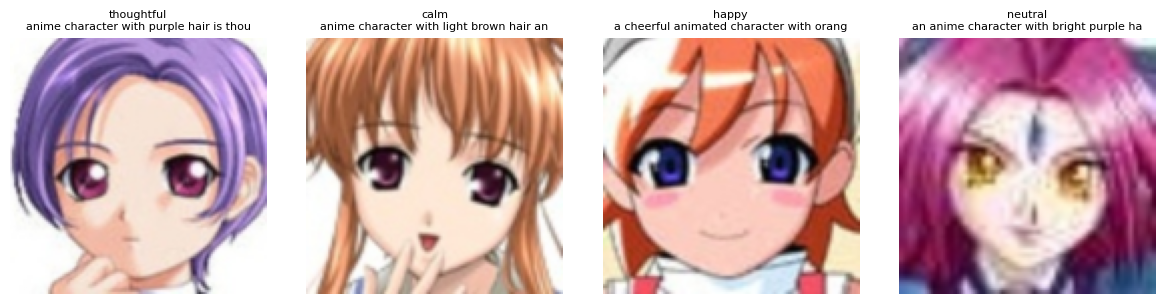

In [33]:
class AnimeCaptionDataset(Dataset):
    def __init__(self, df, img_dir, image_size=128, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        tx = [transforms.Resize((image_size, image_size)),
              transforms.ToTensor(),
              transforms.Normalize([0.5] * 3, [0.5] * 3)]
        if augment:
            tx.insert(1, transforms.RandomHorizontalFlip())
        self.tf = transforms.Compose(tx)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['file'])).convert('RGB')
        img = self.tf(img)
        ids = torch.tensor(encode(str(row['caption'])), dtype=torch.long)
        emo = torch.tensor(emotion_to_id[str(row['emotion'])], dtype=torch.long)
        return img, ids, emo


val_frac = 0.05
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
n_val = max(8, int(len(df_shuffled) * val_frac))
df_train = df_shuffled.iloc[n_val:].reset_index(drop=True)
df_val = df_shuffled.iloc[:n_val].reset_index(drop=True)

IMAGE_SIZE = 128
train_ds = AnimeCaptionDataset(df_train, IMG_DIR, image_size=IMAGE_SIZE, augment=True)
val_ds = AnimeCaptionDataset(df_val, IMG_DIR, image_size=IMAGE_SIZE, augment=False)
print(f'train: {len(train_ds)}, val: {len(val_ds)}')

imgs, ids, emos = next(iter(DataLoader(train_ds, batch_size=4, shuffle=True)))
print(f'images: {imgs.shape}, ids: {ids.shape}, emotions: {emos.tolist()}')
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, im, idv, em in zip(axes, imgs, ids, emos):
    ax.imshow(((im.permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1))
    cap = ' '.join(itos[int(t)] for t in idv if int(t) not in (PAD_ID, CLS_ID, SEP_ID))
    ax.set_title(f'{emotion_classes[em]}\n{cap[:40]}', fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 14b. Build the model with the anime-dataset hyperparameters

A small config that fits the 2000-image dataset and runs on a typical laptop GPU / CPU.


In [36]:
DIM = 256
NUM_CODES = 512
ENC_IMAGE_SIZE = 224
GEN_IMAGE_SIZE = IMAGE_SIZE

def to_8x8(visual_seq):
    """Pool a (B, N, E) sequence into (B, 64, E) by interpolating the square grid down to 8x8."""
    B, N, E = visual_seq.shape
    side = int(math.isqrt(N))
    assert side * side == N, f'visual seq length {N} not square'
    grid = visual_seq.transpose(1, 2).reshape(B, E, side, side)
    grid = F.interpolate(grid, size=(8, 8), mode='bilinear', align_corners=False)
    return grid.flatten(2).transpose(1, 2)

model = XLXMERT(vocab_size=VOCAB_SIZE,
                max_text_len=MAX_LEN,
                dim=DIM,
                n_obj_layers=2, n_lang_layers=2, n_cross_layers=2,
                num_codes=NUM_CODES,
                num_qa_answers=NUM_EMOTIONS,
                heads=8).to(device)        # <-- add this line
G = Generator(in_dim=DIM, label_nc=DIM).to(device)
D = Discriminator(num_classes=NUM_EMOTIONS).to(device)
perceptual = VGGPerceptual().to(device)

def n_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'XLXMERT params:       {n_params(model)/1e6:.2f}M')
print(f'Generator params:     {n_params(G)/1e6:.2f}M')
print(f'Discriminator params: {n_params(D)/1e6:.2f}M')


XLXMERT params:       7.02M
Generator params:     19.37M
Discriminator params: 2.77M


## 14c. Real training loop on the anime dataset

For each batch we:
1. Build masked language-model labels (15% of non-special caption tokens are masked).
2. Build masked visual-token labels (15% of visual patches).
3. Build matching pairs (Yes) and shuffled-text pairs (No) for cross-modality matching.
4. Use `emotion` as the QA target (and as the AC-GAN class target for the discriminator).


In [37]:
def make_mlm_labels(ids, mask_prob=0.15):
    labels = torch.full_like(ids, -100)
    rand = torch.rand(ids.shape, device=ids.device)
    special = (ids == PAD_ID) | (ids == CLS_ID) | (ids == SEP_ID)
    mask = (rand < mask_prob) & ~special
    labels[mask] = ids[mask]
    input_ids = ids.clone()
    input_ids[mask] = MASK_ID
    return input_ids, labels


def make_match_batch(ids):
    """First half = mismatched (label 0), second half = matched (label 1)."""
    B = ids.size(0)
    half = max(1, B // 2)
    match_target = torch.ones(B, dtype=torch.long, device=ids.device)
    perm = (torch.randperm(half, device=ids.device) + 1) % half
    new_ids = ids.clone()
    new_ids[:half] = ids[:half][perm]
    match_target[:half] = 0
    return new_ids, match_target


def train_one_epoch(loader, lambda_fm=10.0, lambda_p=5.0, lambda_ac=1.0,
                    visual_mask_prob=0.15, log_every=20):
    model.train(); G.train(); D.train()
    history = []
    for step, (images, ids, emos) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        ids = ids.to(device, non_blocking=True)
        emos = emos.to(device, non_blocking=True)

        images_enc = F.interpolate(images, size=ENC_IMAGE_SIZE, mode='bilinear', align_corners=False)

        mlm_input, mlm_labels = make_mlm_labels(ids)
        match_ids, match_target = make_match_batch(mlm_input)

        out = model(images_enc, match_ids)
        visual_mask = (torch.rand_like(out['visual_code_targets'], dtype=torch.float32) < visual_mask_prob)
        if visual_mask.sum() == 0:
            visual_mask[:, 0] = True
        e_loss = encoder_pretrain_loss(
            out,
            mlm_targets=mlm_labels,
            qa_target=emos,
            match_target=match_target,
            mask_indices=visual_mask,
        )
        opt_E.zero_grad(set_to_none=True); e_loss.backward(); opt_E.step()

        with torch.no_grad():
            v_seq = model(images_enc, ids)['visual_seq']
        v_seq = to_8x8(v_seq)
        fake = G(v_seq)
        fake_logits, fake_cls, fake_feats = D(fake)
        real_logits, _, real_feats = D(images)
        g_total = (hinge_g_loss(fake_logits)
                   + lambda_fm * feature_matching_loss(real_feats, fake_feats)
                   + lambda_ac * F.cross_entropy(fake_cls, emos)
                   + lambda_p  * perceptual((fake + 1) / 2, (images + 1) / 2))
        opt_G.zero_grad(set_to_none=True); g_total.backward(); opt_G.step()

        real_logits, real_cls, _ = D(images)
        with torch.no_grad():
            v_seq2 = to_8x8(model(images_enc, ids)['visual_seq'])
            fake2 = G(v_seq2)
        fake_logits, _, _ = D(fake2.detach())
        d_total = hinge_d_loss(real_logits, fake_logits) + F.cross_entropy(real_cls, emos)
        opt_D.zero_grad(set_to_none=True); d_total.backward(); opt_D.step()

        history.append((e_loss.item(), g_total.item(), d_total.item()))
        if step % log_every == 0:
            print(f'  step {step:4d} | E {e_loss.item():.3f}  G {g_total.item():.3f}  D {d_total.item():.3f}')
    return history


opt_E = torch.optim.AdamW(model.parameters(), lr=1e-4)
opt_G = torch.optim.AdamW(G.parameters(), lr=2e-4, betas=(0.0, 0.999))
opt_D = torch.optim.AdamW(D.parameters(), lr=2e-4, betas=(0.0, 0.999))

BATCH_SIZE = 8 if device.type == 'cpu' else 16
NUM_EPOCHS = 2 if device.type == 'cpu' else 5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_history = []
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch + 1}/{NUM_EPOCHS}')
    h = train_one_epoch(train_loader, log_every=20)
    all_history.extend(h)



Epoch 1/5


/tmp/ipykernel_9683/116259011.py:24: UserWarning: Using a target size (torch.Size([16, 64, 64, 64])) that is different to the input size (torch.Size([16, 64, 32, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return sum(F.l1_loss(f, r.detach()) for r, f in zip(real_feats, fake_feats)) / len(real_feats)


RuntimeError: The size of tensor a (32) must match the size of tensor b (64) at non-singleton dimension 3

In [38]:
def train_one_epoch(loader, lambda_fm=10.0, lambda_p=5.0, lambda_ac=1.0,
                    visual_mask_prob=0.15, log_every=20):
    model.train(); G.train(); D.train()
    history = []
    for step, (images, ids, emos) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        ids = ids.to(device, non_blocking=True)
        emos = emos.to(device, non_blocking=True)

        images_enc = F.interpolate(images, size=ENC_IMAGE_SIZE,
                                   mode='bilinear', align_corners=False)

        mlm_input, mlm_labels = make_mlm_labels(ids)
        match_ids, match_target = make_match_batch(mlm_input)

        out = model(images_enc, match_ids)
        visual_mask = (torch.rand_like(out['visual_code_targets'],
                                       dtype=torch.float32) < visual_mask_prob)
        if visual_mask.sum() == 0:
            visual_mask[:, 0] = True
        e_loss = encoder_pretrain_loss(
            out,
            mlm_targets=mlm_labels,
            qa_target=emos,
            match_target=match_target,
            mask_indices=visual_mask,
        )
        opt_E.zero_grad(set_to_none=True); e_loss.backward(); opt_E.step()

        # ---- Generator step ----
        with torch.no_grad():
            v_seq = model(images_enc, ids)['visual_seq']
        v_seq = to_8x8(v_seq)
        fake = G(v_seq)                              # 64x64

        # MATCH the discriminator's input resolution: resize real images
        # down to whatever spatial size the generator produced.
        images_d = F.interpolate(images, size=fake.shape[-1],
                                 mode='bilinear', align_corners=False)

        fake_logits, fake_cls, fake_feats = D(fake)
        real_logits, _, real_feats = D(images_d)
        g_total = (hinge_g_loss(fake_logits)
                   + lambda_fm * feature_matching_loss(real_feats, fake_feats)
                   + lambda_ac * F.cross_entropy(fake_cls, emos)
                   + lambda_p  * perceptual((fake + 1) / 2,
                                            (images_d + 1) / 2))
        opt_G.zero_grad(set_to_none=True); g_total.backward(); opt_G.step()

        # ---- Discriminator step ----
        real_logits, real_cls, _ = D(images_d)
        with torch.no_grad():
            v_seq2 = to_8x8(model(images_enc, ids)['visual_seq'])
            fake2 = G(v_seq2)
        fake_logits, _, _ = D(fake2.detach())
        d_total = hinge_d_loss(real_logits, fake_logits) \
                  + F.cross_entropy(real_cls, emos)
        opt_D.zero_grad(set_to_none=True); d_total.backward(); opt_D.step()

        history.append((e_loss.item(), g_total.item(), d_total.item()))
        if step % log_every == 0:
            print(f'  step {step:4d} | E {e_loss.item():.3f}  '
                  f'G {g_total.item():.3f}  D {d_total.item():.3f}')
    return history

In [39]:
def make_mlm_labels(ids, mask_prob=0.15):
    labels = torch.full_like(ids, -100)
    rand = torch.rand(ids.shape, device=ids.device)
    special = (ids == PAD_ID) | (ids == CLS_ID) | (ids == SEP_ID)
    mask = (rand < mask_prob) & ~special
    labels[mask] = ids[mask]
    input_ids = ids.clone()
    input_ids[mask] = MASK_ID
    return input_ids, labels


def make_match_batch(ids):
    """First half = mismatched (label 0), second half = matched (label 1)."""
    B = ids.size(0)
    half = max(1, B // 2)
    match_target = torch.ones(B, dtype=torch.long, device=ids.device)
    perm = (torch.randperm(half, device=ids.device) + 1) % half
    new_ids = ids.clone()
    new_ids[:half] = ids[:half][perm]
    match_target[:half] = 0
    return new_ids, match_target


def train_one_epoch(loader, lambda_fm=10.0, lambda_p=5.0, lambda_ac=1.0,
                    visual_mask_prob=0.15, log_every=20):
    model.train(); G.train(); D.train()
    history = []
    for step, (images, ids, emos) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        ids    = ids.to(device, non_blocking=True)
        emos   = emos.to(device, non_blocking=True)

        # Encoder sees 224x224 (ViT-style)
        images_enc = F.interpolate(images, size=ENC_IMAGE_SIZE,
                                   mode='bilinear', align_corners=False)

        # ---- 1. Encoder pre-training ----
        mlm_input, mlm_labels = make_mlm_labels(ids)
        match_ids, match_target = make_match_batch(mlm_input)

        out = model(images_enc, match_ids)
        visual_mask = (torch.rand_like(out['visual_code_targets'],
                                       dtype=torch.float32) < visual_mask_prob)
        if visual_mask.sum() == 0:
            visual_mask[:, 0] = True
        e_loss = encoder_pretrain_loss(
            out,
            mlm_targets=mlm_labels,
            qa_target=emos,
            match_target=match_target,
            mask_indices=visual_mask,
        )
        opt_E.zero_grad(set_to_none=True); e_loss.backward(); opt_E.step()

        # ---- 2. Generator step ----
        with torch.no_grad():
            v_seq = model(images_enc, ids)['visual_seq']
        v_seq = to_8x8(v_seq)
        fake  = G(v_seq)                              # 64x64

        # Match the discriminator's input resolution: resize real images
        # down to whatever spatial size the generator produced.
        images_d = F.interpolate(images, size=fake.shape[-1],
                                 mode='bilinear', align_corners=False)

        fake_logits, fake_cls, fake_feats = D(fake)
        real_logits, _,        real_feats = D(images_d)
        g_total = (hinge_g_loss(fake_logits)
                   + lambda_fm * feature_matching_loss(real_feats, fake_feats)
                   + lambda_ac * F.cross_entropy(fake_cls, emos)
                   + lambda_p  * perceptual((fake + 1) / 2,
                                            (images_d + 1) / 2))
        opt_G.zero_grad(set_to_none=True); g_total.backward(); opt_G.step()

        # ---- 3. Discriminator step ----
        real_logits, real_cls, _ = D(images_d)
        with torch.no_grad():
            v_seq2 = to_8x8(model(images_enc, ids)['visual_seq'])
            fake2  = G(v_seq2)
        fake_logits, _, _ = D(fake2.detach())
        d_total = hinge_d_loss(real_logits, fake_logits) \
                  + F.cross_entropy(real_cls, emos)
        opt_D.zero_grad(set_to_none=True); d_total.backward(); opt_D.step()

        history.append((e_loss.item(), g_total.item(), d_total.item()))
        if step % log_every == 0:
            print(f'  step {step:4d} | E {e_loss.item():.3f}  '
                  f'G {g_total.item():.3f}  D {d_total.item():.3f}')
    return history


# ---- Optimizers, dataloaders, training loop ----
opt_E = torch.optim.AdamW(model.parameters(),  lr=1e-4)
opt_G = torch.optim.AdamW(G.parameters(),      lr=2e-4, betas=(0.0, 0.999))
opt_D = torch.optim.AdamW(D.parameters(),      lr=2e-4, betas=(0.0, 0.999))

BATCH_SIZE = 8 if device.type == 'cpu' else 16
NUM_EPOCHS = 2 if device.type == 'cpu' else 5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)

all_history = []
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch + 1}/{NUM_EPOCHS}')
    h = train_one_epoch(train_loader, log_every=20)
    all_history.extend(h)


Epoch 1/5
  step    0 | E 15.236  G 3.793  D 4.643
  step   20 | E 10.314  G 3.102  D 3.975
  step   40 | E 9.629  G 3.238  D 4.086
  step   60 | E 8.462  G 2.424  D 3.780
  step   80 | E 7.051  G 2.491  D 3.884
  step  100 | E 7.053  G 2.565  D 3.837

Epoch 2/5
  step    0 | E 6.202  G 1.671  D 3.240
  step   20 | E 4.944  G 2.375  D 3.782
  step   40 | E 7.199  G 3.204  D 4.395
  step   60 | E 6.388  G 2.287  D 3.816
  step   80 | E 5.841  G 2.140  D 3.594
  step  100 | E 6.636  G 3.098  D 4.116

Epoch 3/5
  step    0 | E 7.659  G 2.835  D 4.306
  step   20 | E 5.315  G 2.577  D 4.038
  step   40 | E 5.631  G 2.360  D 3.891
  step   60 | E 5.224  G 2.031  D 3.442
  step   80 | E 6.464  G 3.629  D 4.010
  step  100 | E 5.476  G 2.359  D 3.566

Epoch 4/5
  step    0 | E 6.695  G 2.434  D 3.755
  step   20 | E 5.818  G 2.612  D 3.942
  step   40 | E 5.368  G 2.314  D 3.706
  step   60 | E 5.662  G 2.401  D 3.785
  step   80 | E 4.993  G 2.061  D 3.615
  step  100 | E 6.162  G 2.420  D 

## 14d. Visualize generated images and compute IS / FID on the validation split


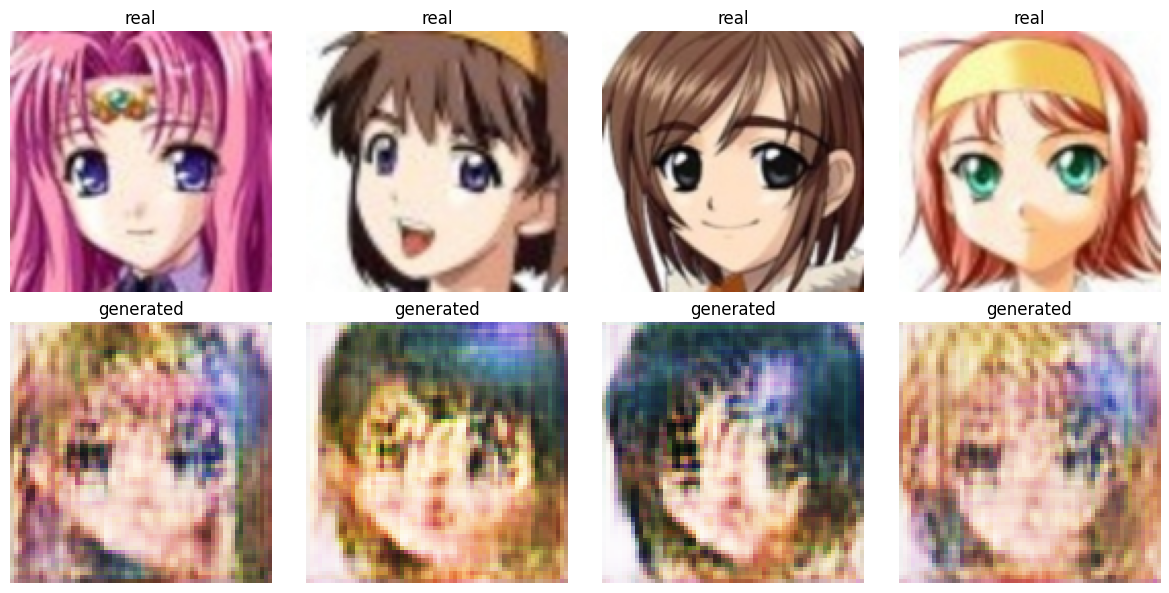

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 239MB/s] 


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [32, 1000]

In [40]:
@torch.no_grad()
def generate_for_loader(loader, max_batches=None):
    model.eval(); G.eval()
    fakes, reals = [], []
    for i, (images, ids, _) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        images = images.to(device); ids = ids.to(device)
        images_enc = F.interpolate(images, size=ENC_IMAGE_SIZE, mode='bilinear', align_corners=False)
        v_seq = to_8x8(model(images_enc, ids)['visual_seq'])
        fake = G(v_seq)
        fakes.append(fake.cpu()); reals.append(images.cpu())
    return torch.cat(reals), torch.cat(fakes)


real_imgs, fake_imgs = generate_for_loader(val_loader)

n_show = min(4, real_imgs.size(0))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(((real_imgs[i].permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy())
    axes[0, i].set_title('real'); axes[0, i].axis('off')
    axes[1, i].imshow(((fake_imgs[i].permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy())
    axes[1, i].set_title('generated'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

real_imgs_d = real_imgs.to(device)
fake_imgs_d = fake_imgs.to(device)
is_mean, is_std = inception_score(fake_imgs_d, n_splits=min(10, fake_imgs_d.size(0)))
fid = fid_score(real_imgs_d, fake_imgs_d)
print(f'Validation Inception Score: {is_mean:.3f} +/- {is_std:.3f}')
print(f'Validation FID            : {fid:.3f}')


In [41]:
@torch.no_grad()
def _inception_features(images, batch_size=32):
    """Extract 2048-D pool3 features from InceptionV3 via a forward hook."""
    inc = _load_inception()

    feats_buffer = []
    def hook(module, _input, output):
        feats_buffer.append(output.flatten(1).cpu().numpy())

    handle = inc.avgpool.register_forward_hook(hook)
    try:
        x = F.interpolate((images + 1) / 2, size=(299, 299),
                          mode='bilinear', align_corners=False)
        mean = torch.tensor([0.485, 0.456, 0.406],
                            device=images.device).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225],
                            device=images.device).view(1, 3, 1, 1)
        x = (x - mean) / std
        for i in range(0, x.size(0), batch_size):
            _ = inc(x[i:i + batch_size])     # output ignored; hook captures pool3
    finally:
        handle.remove()

    return np.concatenate(feats_buffer, axis=0)


def fid_score(real_images, fake_images):
    real_feats = _inception_features(real_images)
    fake_feats = _inception_features(fake_images)
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_g
    covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_r + sigma_g - 2 * covmean))

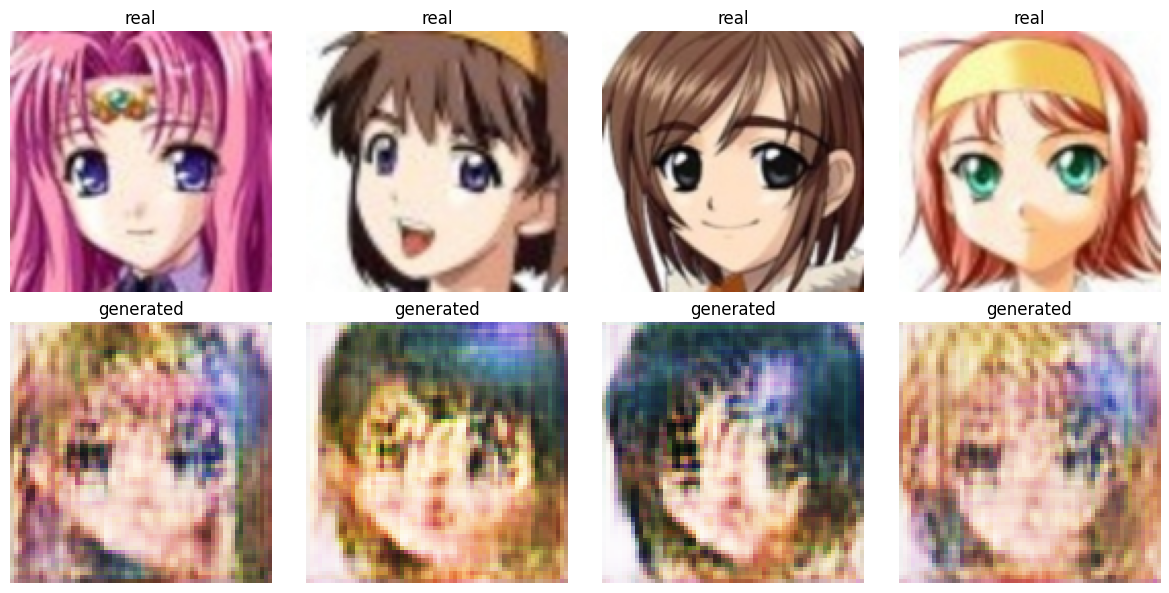

/tmp/ipykernel_9683/919387714.py:34: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_g, disp=False)


Validation Inception Score: 2.043 +/- 0.163
Validation FID            : 319.750


In [42]:
real_imgs, fake_imgs = generate_for_loader(val_loader)

n_show = min(4, real_imgs.size(0))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(((real_imgs[i].permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy())
    axes[0, i].set_title('real'); axes[0, i].axis('off')
    axes[1, i].imshow(((fake_imgs[i].permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy())
    axes[1, i].set_title('generated'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

real_imgs_d = real_imgs.to(device)
fake_imgs_d = fake_imgs.to(device)
is_mean, is_std = inception_score(fake_imgs_d, n_splits=min(10, fake_imgs_d.size(0)))
fid = fid_score(real_imgs_d, fake_imgs_d)
print(f'Validation Inception Score: {is_mean:.3f} +/- {is_std:.3f}')
print(f'Validation FID            : {fid:.3f}')


## 14e. Caption generation - greedy decode using the trained encoder + decoder


In [43]:
decoder = CaptionDecoder(vocab_size=VOCAB_SIZE, dim=DIM, n_layers=2, max_len=MAX_LEN).to(device)
opt_dec = torch.optim.AdamW(decoder.parameters(), lr=2e-4)

def train_caption_decoder(loader, n_epochs=2):
    model.eval(); decoder.train()
    for epoch in range(n_epochs):
        total = 0.0; nstep = 0
        for images, ids, _ in loader:
            images = images.to(device); ids = ids.to(device)
            images_enc = F.interpolate(images, size=ENC_IMAGE_SIZE, mode='bilinear', align_corners=False)
            with torch.no_grad():
                memory = model(images_enc, ids)['visual_seq']
            tgt_in = ids[:, :-1]; tgt_out = ids[:, 1:]
            logits = decoder(tgt_in, memory)
            loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1),
                                   ignore_index=PAD_ID)
            opt_dec.zero_grad(set_to_none=True); loss.backward(); opt_dec.step()
            total += loss.item(); nstep += 1
        print(f'caption decoder epoch {epoch + 1}: avg loss {total / max(1, nstep):.3f}')

train_caption_decoder(train_loader, n_epochs=2 if device.type == 'cpu' else 3)


@torch.no_grad()
def generate_caption(image_tensor, max_len=MAX_LEN):
    model.eval(); decoder.eval()
    img = image_tensor.unsqueeze(0).to(device)
    img_enc = F.interpolate(img, size=ENC_IMAGE_SIZE, mode='bilinear', align_corners=False)
    seed = torch.full((1, MAX_LEN), PAD_ID, dtype=torch.long, device=device)
    seed[0, 0] = CLS_ID
    memory = model(img_enc, seed)['visual_seq']
    cur = [CLS_ID]
    for _ in range(max_len - 1):
        ids = torch.tensor([cur], device=device)
        logits = decoder(ids, memory)
        nxt = int(logits[0, -1].argmax().item())
        if nxt == SEP_ID or nxt == PAD_ID:
            break
        cur.append(nxt)
    return ' '.join(itos[i] for i in cur if i not in (CLS_ID, SEP_ID, PAD_ID))


for i in range(min(4, len(val_ds))):
    img, ids, emo = val_ds[i]
    pred = generate_caption(img)
    gold = ' '.join(itos[int(t)] for t in ids if int(t) not in (PAD_ID, CLS_ID, SEP_ID))
    print(f'\n[{emotion_classes[int(emo)]}]')
    print(f'  gold: {gold}')
    print(f'  pred: {pred}')


caption decoder epoch 1: avg loss 2.758
caption decoder epoch 2: avg loss 1.921
caption decoder epoch 3: avg loss 1.715

[neutral]
  gold: anime character with long pink hair vibrant purple eyes and an ornate jeweled headband
  pred: a cheerful anime character with long blonde hair and a gentle smile

[happy]
  gold: a cheerful anime character with brown hair and a headband smiling brightly
  pred: a cheerful anime character with long brown hair and a gentle smile

[happy]
  gold: a smiling anime character with brown hair and big eyes
  pred: a cheerful anime character with long brown hair and a gentle smile

[neutral]
  gold: a stylized anime character with vibrant green eyes short reddish brown hair and a yellow headband
  pred: a cheerful anime character with long blonde hair and bright eyes


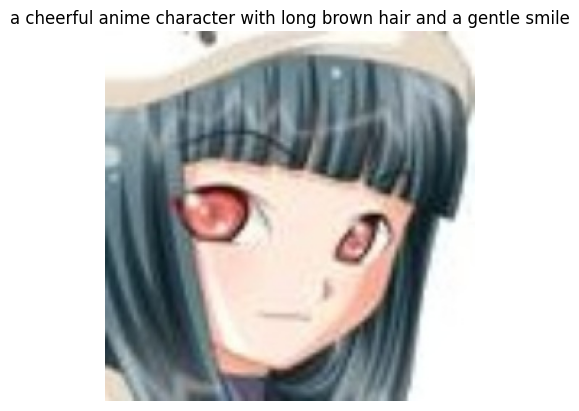

Caption: a cheerful anime character with long brown hair and a gentle smile


In [48]:
# === Test: generate a caption for any image ===
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def load_image(path_or_url, image_size=IMAGE_SIZE):
    """Accepts a local path or http(s) URL. Returns a normalized tensor on `device`."""
    if str(path_or_url).startswith(('http://', 'https://')):
        import io, requests
        img = Image.open(io.BytesIO(requests.get(path_or_url).content)).convert('RGB')
    else:
        img = Image.open(path_or_url).convert('RGB')
    tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    return img, tf(img).to(device)


# --- Pick an image ---
# Option A: local file (e.g. one you uploaded to Colab via the Files panel)
img_path = '/content/drive/MyDrive/LJMUThesis/anime_xformer/data/anime_images/1.jpg'
# Option B: URL
# img_path = 'https://example.com/anime_face.jpg'
# Option C: upload from your computer
# from google.colab import files; up = files.upload(); img_path = next(iter(up))

pil_img, img_tensor = load_image(img_path)
caption = generate_caption(img_tensor)

plt.imshow(pil_img); plt.axis('off'); plt.title(caption); plt.show()
print('Caption:', caption)

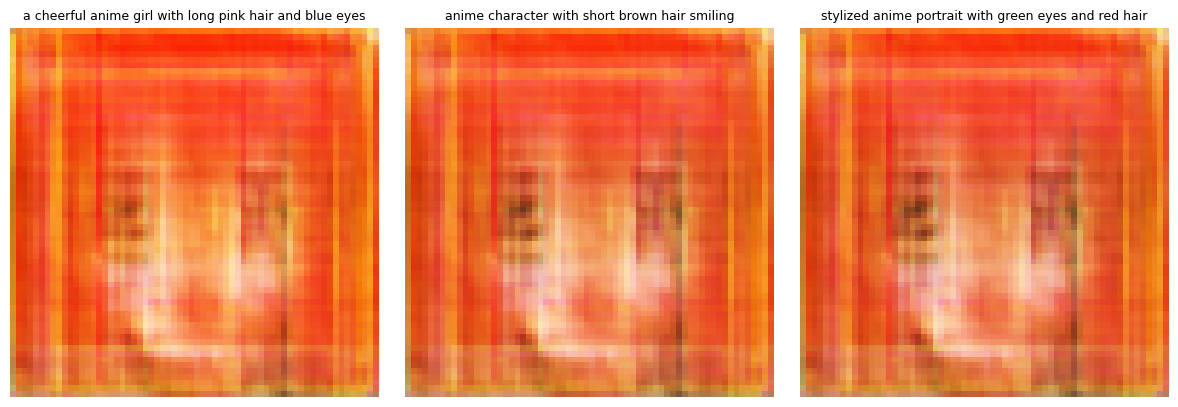

In [49]:
# === Test: generate an image from a free-form caption ===
@torch.no_grad()
def generate_image_from_caption(caption_str, ref_image=None):
    """
    Generates a 64x64 image conditioned on `caption_str`.
    Needs a reference image because the encoder is multimodal (it expects both).
    If ref_image is None we use a gray placeholder.
    """
    model.eval(); G.eval()

    ids = torch.tensor([encode(caption_str)], dtype=torch.long, device=device)

    if ref_image is None:
        ref = torch.zeros(1, 3, ENC_IMAGE_SIZE, ENC_IMAGE_SIZE, device=device)
    else:
        ref = F.interpolate(ref_image.unsqueeze(0), size=ENC_IMAGE_SIZE,
                            mode='bilinear', align_corners=False)

    v_seq = to_8x8(model(ref, ids)['visual_seq'])
    fake = G(v_seq)
    img = ((fake[0].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
    return img


# --- Try a few captions ---
test_captions = [
    "a cheerful anime girl with long pink hair and blue eyes",
    "anime character with short brown hair smiling",
    "stylized anime portrait with green eyes and red hair",
]

fig, axes = plt.subplots(1, len(test_captions), figsize=(4 * len(test_captions), 4))
for ax, cap in zip(axes, test_captions):
    img = generate_image_from_caption(cap)
    ax.imshow(img); ax.axis('off')
    ax.set_title(cap, fontsize=9, wrap=True)
plt.tight_layout(); plt.show()

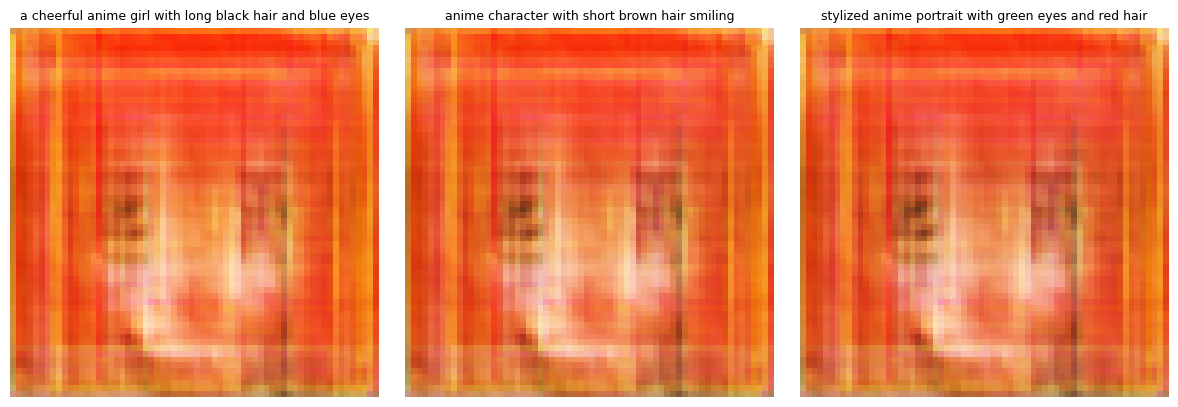

In [51]:
# === Test: generate an image from a free-form caption ===
@torch.no_grad()
def generate_image_from_caption(caption_str, ref_image=None):
    """
    Generates a 64x64 image conditioned on `caption_str`.
    Needs a reference image because the encoder is multimodal (it expects both).
    If ref_image is None we use a gray placeholder.
    """
    model.eval(); G.eval()

    ids = torch.tensor([encode(caption_str)], dtype=torch.long, device=device)

    if ref_image is None:
        ref = torch.zeros(1, 3, ENC_IMAGE_SIZE, ENC_IMAGE_SIZE, device=device)
    else:
        ref = F.interpolate(ref_image.unsqueeze(0), size=ENC_IMAGE_SIZE,
                            mode='bilinear', align_corners=False)

    v_seq = to_8x8(model(ref, ids)['visual_seq'])
    fake = G(v_seq)
    img = ((fake[0].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
    return img


# --- Try a few captions ---
test_captions = [
    "a cheerful anime girl with long black hair and blue eyes",
    "anime character with short brown hair smiling",
    "stylized anime portrait with green eyes and red hair",
]

fig, axes = plt.subplots(1, len(test_captions), figsize=(4 * len(test_captions), 4))
for ax, cap in zip(axes, test_captions):
    img = generate_image_from_caption(cap)
    ax.imshow(img); ax.axis('off')
    ax.set_title(cap, fontsize=9, wrap=True)
plt.tight_layout(); plt.show()

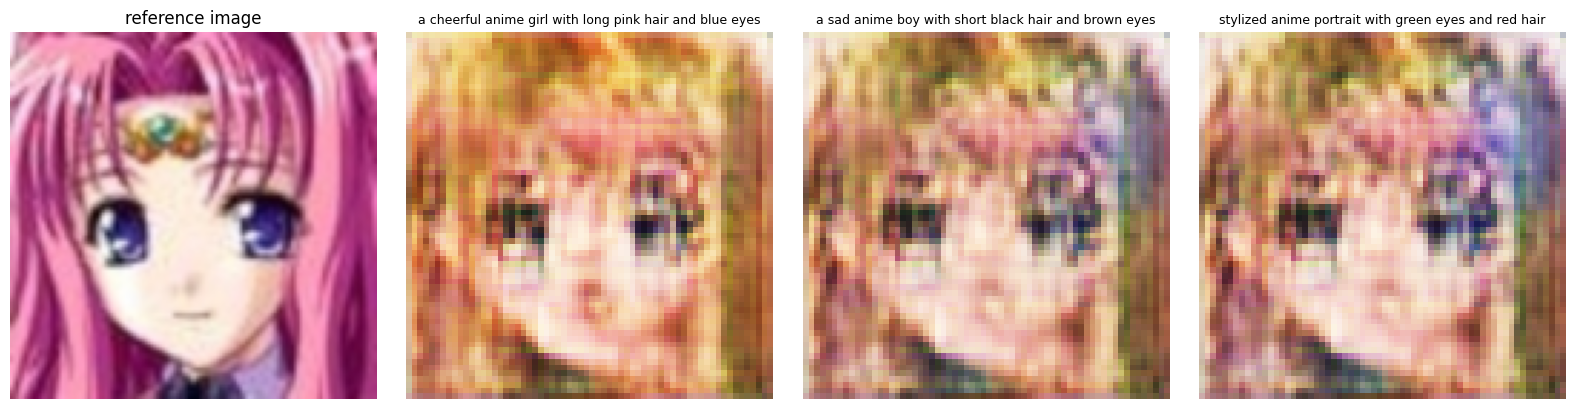

In [52]:
# Pick one validation image as reference
ref_img, ref_ids, _ = val_ds[0]
ref_img = ref_img.to(device)

test_captions = [
    "a cheerful anime girl with long pink hair and blue eyes",
    "a sad anime boy with short black hair and brown eyes",
    "stylized anime portrait with green eyes and red hair",
]

fig, axes = plt.subplots(1, len(test_captions) + 1, figsize=(4 * (len(test_captions) + 1), 4))
axes[0].imshow(((ref_img.cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy())
axes[0].axis('off'); axes[0].set_title('reference image')

for ax, cap in zip(axes[1:], test_captions):
    img = generate_image_from_caption(cap, ref_image=ref_img)
    ax.imshow(img); ax.axis('off')
    ax.set_title(cap, fontsize=9, wrap=True)

plt.tight_layout(); plt.show()

## 14f. Save / load checkpoints


In [44]:
ckpt_dir = os.path.join(os.getcwd(), 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
ckpt = {
    'xlxmert': model.state_dict(),
    'generator': G.state_dict(),
    'discriminator': D.state_dict(),
    'caption_decoder': decoder.state_dict(),
    'vocab': {'stoi': stoi, 'itos': {int(k): v for k, v in itos.items()},
              'specials': {'pad': PAD_ID, 'cls': CLS_ID, 'sep': SEP_ID, 'mask': MASK_ID, 'unk': UNK_ID}},
    'emotion_classes': emotion_classes,
    'config': {'dim': DIM, 'num_codes': NUM_CODES, 'max_len': MAX_LEN,
               'enc_image_size': ENC_IMAGE_SIZE, 'gen_image_size': GEN_IMAGE_SIZE},
}
ckpt_path = os.path.join(ckpt_dir, 'xlxmert_anime.pt')
torch.save(ckpt, ckpt_path)
print(f'Saved -> {ckpt_path}')


Saved -> /content/checkpoints/xlxmert_anime.pt


## 15. Notes for production use

- Replace `TextEmbedding` with a real tokenizer (e.g. `BertTokenizerFast`) and use the BERT vocab size.  
- For large-scale training, initialise `XLXMERT` from a pre-trained LXMERT checkpoint (`unc-nlp/lxmert-base-uncased` on Hugging Face) and only re-train the visual front-end.  
- The visual codebook (`VisualQuantizer`) should be trained on a large image corpus before encoder pre-training, exactly as in Cho et al. (2020).  
- IS/FID are only meaningful with downloaded ImageNet-pretrained Inception V3 weights and at least a few thousand generated images.